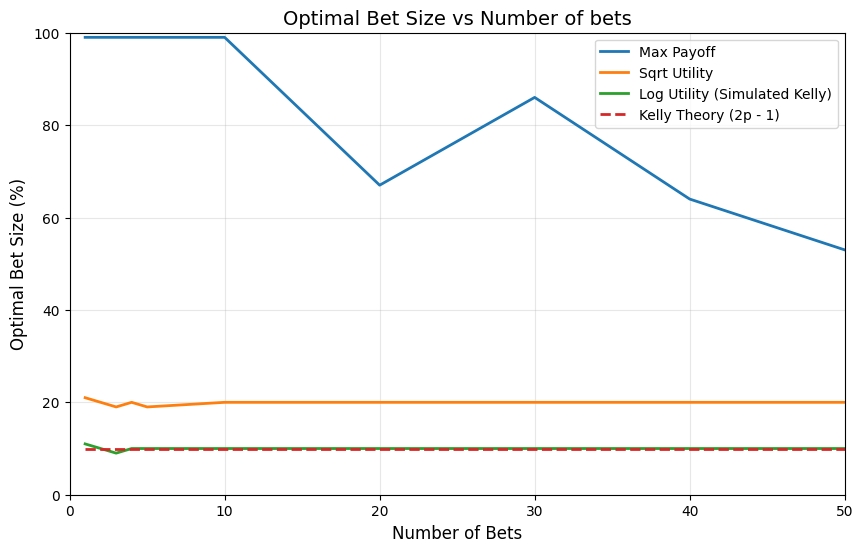

In [1]:
import numpy as np
import matplotlib.pyplot as plt
win_prob = 0.55
num_simulations = 10000
starting_money = 100
num_bets_options = [1,2,3,4,5,10,20,30,40,50] # 100 hits kelly equilibrium so test lower
highest_payoffs = []
highest_sqrt_utilities = []
highest_log_utilities = []
kelly_optimal_choice = []

for num_bets in num_bets_options:
    avg_payoffs = []
    avg_sqrt_utilities = []
    avg_log_utilities = []
    wins_matrix = np.random.rand(num_simulations, num_bets) < win_prob

    # run simulations
    for bet_percentage in range (100):  #(0-99) (100% will lost money with certainty in long run)
        money = np.full((num_simulations,), starting_money, dtype = float)
        for i in range(num_bets):
            bet = bet_percentage * money / 100
            money[wins_matrix[:, i]] += bet[wins_matrix[:, i]]
            money[~wins_matrix[:, i]] -= bet[~wins_matrix[:, i]]
        
        avg_payoff = np.mean(money)
        avg_sqrt_utility = np.mean(np.sqrt(money))
        avg_log_utility = np.mean(np.log(np.maximum(money,1e-100))) # disallow money from dropping to 0 (or arbitrarily close)
        
        
        returns = (money - starting_money) / starting_money
        avg_return = np.mean(returns)

        avg_payoffs.append([bet_percentage, avg_payoff])
        avg_sqrt_utilities.append([bet_percentage, avg_sqrt_utility])
        avg_log_utilities.append([bet_percentage, avg_log_utility])
        

    # Convert to arrays
    avg_payoffs = np.array(avg_payoffs)
    avg_sqrt_utilities = np.array(avg_sqrt_utilities)
    avg_log_utilities = np.array(avg_log_utilities)


    # Find the index of the max value
    best_payoff_idx = np.argmax(avg_payoffs[:, 1])
    best_sqrt_utility_idx = np.argmax(avg_sqrt_utilities[:, 1])
    best_log_utility_idx = np.argmax(avg_log_utilities[:, 1])
    
    highest_payoffs.append(avg_payoffs[best_payoff_idx, 0])
    highest_sqrt_utilities.append(avg_sqrt_utilities[best_sqrt_utility_idx, 0])
    highest_log_utilities.append(avg_log_utilities[best_log_utility_idx, 0])

    #kelly values
    win_value = 1 #payoff = bet size
    kelly_optimal = ((win_value * win_prob)-(1-win_prob))/win_value
    kelly_optimal_choice.append([num_bets, kelly_optimal])

highest_payoffs = np.array(highest_payoffs)
highest_sqrt_utilities = np.array(highest_sqrt_utilities)
highest_log_utilities = np.array(highest_log_utilities)
kelly_optimal_choice = np.array(kelly_optimal_choice)
num_bets_options = np.array(num_bets_options)

plt.figure(figsize=(10,6))

# Plot simulated optimal strategies
plt.plot(num_bets_options, highest_payoffs, label="Max Payoff", linewidth=2)
plt.plot(num_bets_options, highest_sqrt_utilities, label="Sqrt Utility", linewidth=2)
plt.plot(num_bets_options, highest_log_utilities, label="Log Utility (Simulated Kelly)", linewidth=2)

# Plot theoretical Kelly
plt.plot(
    kelly_optimal_choice[:,0],
    kelly_optimal_choice[:,1] * 100,   # convert to %
    linestyle='--',
    linewidth=2,
    label="Kelly Theory (2p - 1)"
)

# Labels
plt.xlabel("Number of Bets", fontsize=12)
plt.ylabel("Optimal Bet Size (%)", fontsize=12)
plt.title("Optimal Bet Size vs Number of bets", fontsize=14)

# Formatting
plt.legend()
plt.grid(alpha=0.3)

#set_axis
plt.xlim(0, 50)
plt.ylim(0, 100)

plt.show()

